# 01 Activity Matrix QC and Heatmaps

Standalone layer that reads saved outputs and regenerates matrix QC plots. It does not depend on variables from the original notebook.

In [1]:
from pathlib import Path
import sys

module_dir = Path.cwd()
if not (module_dir / "functional_analysis_utils.py").exists() and (Path.cwd() / "funconn-analysis" / "functional_analysis_utils.py").exists():
    module_dir = Path.cwd() / "funconn-analysis"
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from functional_analysis_utils import (
    RUN_DATE,
    eigenspectrum_desc,
    eigenspectrum_summary,
    fit_power_law_positive,
    functional_paths,
    matrix_abs_limit,
    plot_power_law_fit,
    plot_positive_eigenvalues,
    plot_subsampled_eigenspectrum,
    read_matrix_csv,
    save_eigenspectrum_csv,
    save_matrix,
    sorted_diagonal_spectrum,
)

sns.set_theme(style="white", context="notebook")
paths = functional_paths()
CORR_DIR = paths["correlation"]
EIGEN_DIR = paths["coupling_eigen"]
LAYER_DIR = paths["layer_annotation"]
print("Functional output:", paths["functional_base"])


Functional output: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03


In [2]:
corr_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_correlation_matrix.csv")
cov_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_covariance_matrix.csv")
normalized_cov_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv")
units_used = pd.read_csv(CORR_DIR / "V1_col_7_4_units_used.csv")
layer_annotations = pd.read_csv(LAYER_DIR / "V1_col_7_4_root_id_layer_annotations.csv")

unit_ids = corr_df.index.astype(int).to_numpy()
print("Correlation shape:", corr_df.shape)
print("Covariance shape:", cov_df.shape)
print("Normalized covariance Tr(C)/N:", np.trace(normalized_cov_df.to_numpy(float)) / normalized_cov_df.shape[0])
print("Correlation diagonal min/max:", np.diag(corr_df.to_numpy(float)).min(), np.diag(corr_df.to_numpy(float)).max())


Correlation shape: (126, 126)
Covariance shape: (126, 126)
Normalized covariance Tr(C)/N: 1.0000000000000002
Correlation diagonal min/max: 0.9999999999999998 1.0


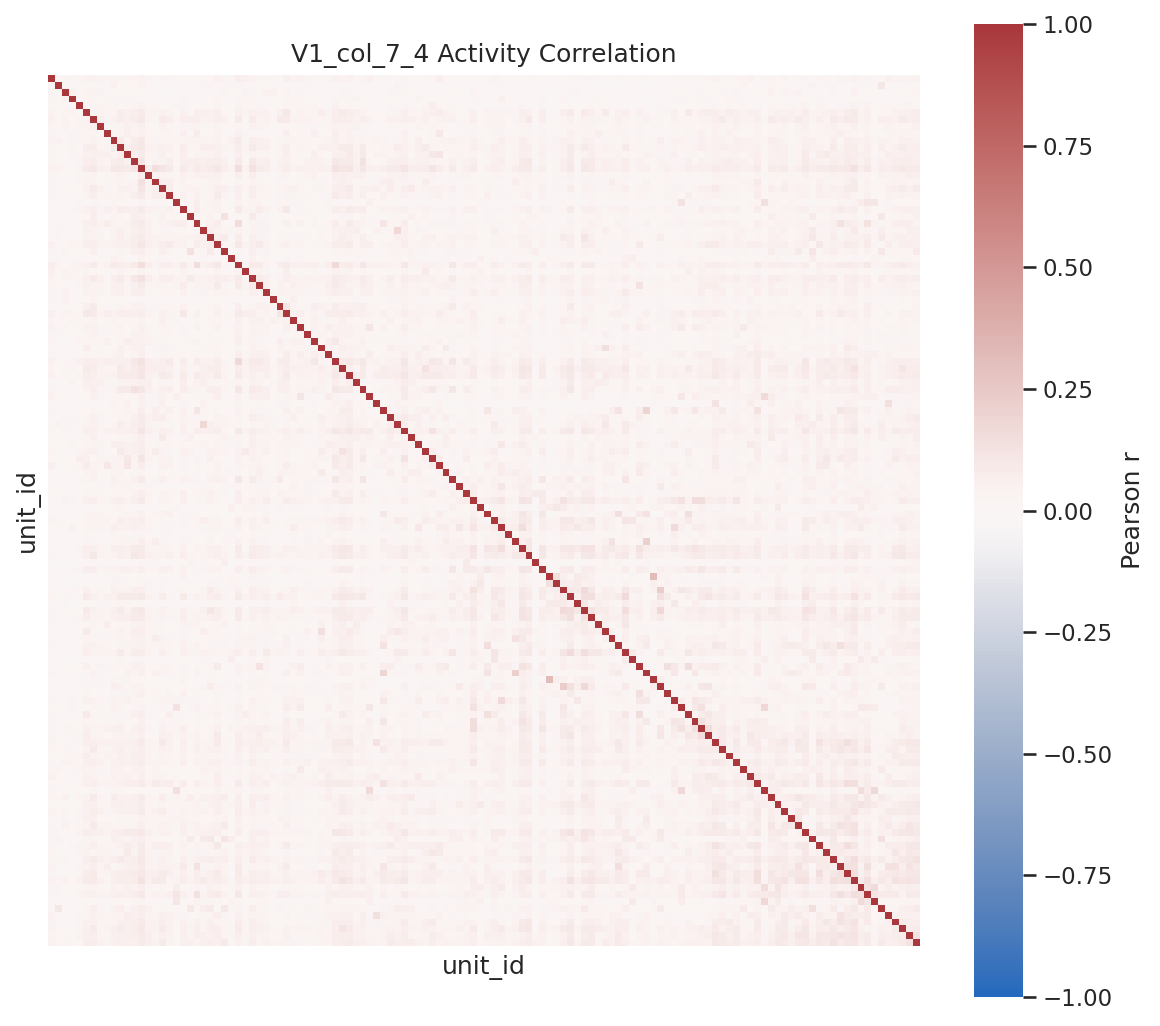

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_heatmap.png


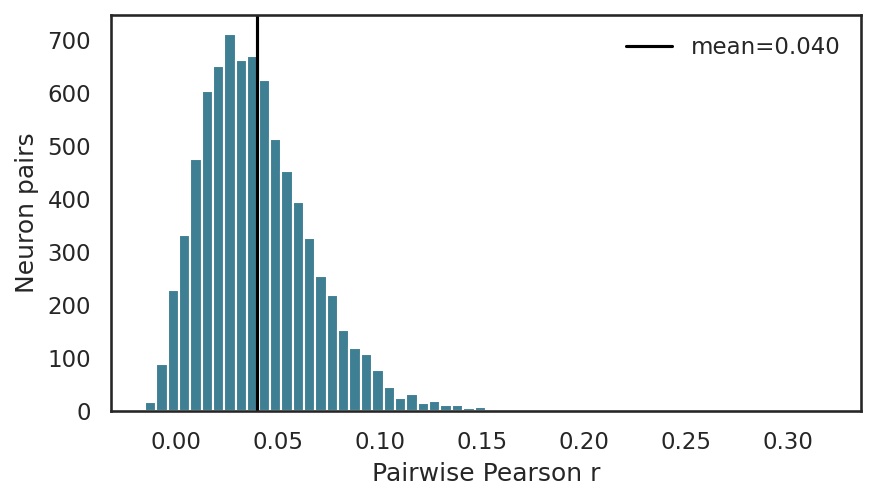

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_distribution.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
sns.heatmap(corr_df, cmap="vlag", center=0, vmin=-1, vmax=1, xticklabels=False, yticklabels=False, square=True, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("V1_col_7_4 Activity Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
path = CORR_DIR / "V1_col_7_4_activity_correlation_heatmap.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)

corr = corr_df.to_numpy(float)
upper = corr[np.triu_indices_from(corr, k=1)]
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)
ax.hist(upper[np.isfinite(upper)], bins=60, color="#3f7f93", edgecolor="white")
ax.axvline(np.nanmean(upper), color="black", lw=1.5, label=f"mean={np.nanmean(upper):.3f}")
ax.set_xlabel("Pairwise Pearson r")
ax.set_ylabel("Neuron pairs")
ax.legend(frameon=False)
fig.tight_layout()
path = CORR_DIR / "V1_col_7_4_activity_correlation_distribution.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


In [4]:
LAYER_ORDER = ["L2/3", "L4", "L5", "Unsure/Other", "Missing"]
CELL_TYPE_ORDER = ["23P", "4P", "5P-IT", "5P-PT", "Unsure E", "Missing"]
LAYER_PALETTE = {"L2/3": "#4C78A8", "L4": "#F58518", "L5": "#54A24B", "Unsure/Other": "#9E9E9E", "Missing": "#D3D3D3"}

valid_layer_info = pd.DataFrame({"unit_id": unit_ids}).merge(
    layer_annotations[["unit_id", "pt_root_id", "allen_slanted_cell_type", "allen_slanted_layer"]],
    on="unit_id",
    how="left",
)
valid_layer_info["allen_slanted_layer"] = valid_layer_info["allen_slanted_layer"].fillna("Missing")
valid_layer_info["allen_slanted_cell_type"] = valid_layer_info["allen_slanted_cell_type"].fillna("Missing")
valid_layer_info["layer_rank"] = valid_layer_info["allen_slanted_layer"].map({layer: i for i, layer in enumerate(LAYER_ORDER)}).fillna(len(LAYER_ORDER))
valid_layer_info["cell_type_rank"] = valid_layer_info["allen_slanted_cell_type"].map({cell_type: i for i, cell_type in enumerate(CELL_TYPE_ORDER)}).fillna(len(CELL_TYPE_ORDER))
valid_layer_info = valid_layer_info.sort_values(["layer_rank", "cell_type_rank", "unit_id"]).reset_index(drop=True)
sorted_unit_ids = valid_layer_info["unit_id"].to_numpy(dtype=int)

layer_color_values = valid_layer_info.set_index("unit_id").loc[sorted_unit_ids, "allen_slanted_layer"].map(LAYER_PALETTE).fillna(LAYER_PALETTE["Missing"])
layer_color_df = pd.DataFrame({"Allen layer": layer_color_values}, index=sorted_unit_ids)
legend_handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=8, label=layer) for layer, color in LAYER_PALETTE.items() if layer in set(valid_layer_info["allen_slanted_layer"])]
valid_layer_info[["unit_id", "pt_root_id", "allen_slanted_cell_type", "allen_slanted_layer"]].to_csv(CORR_DIR / "V1_col_7_4_activity_covariance_allen_layer_sorted_units.csv", index=False)
display(valid_layer_info["allen_slanted_layer"].value_counts().rename_axis("allen_slanted_layer").reset_index(name="n_units"))


,allen_slanted_layer,n_units
0,L2/3,60
1,L4,35
2,L5,29
3,Unsure/Other,2


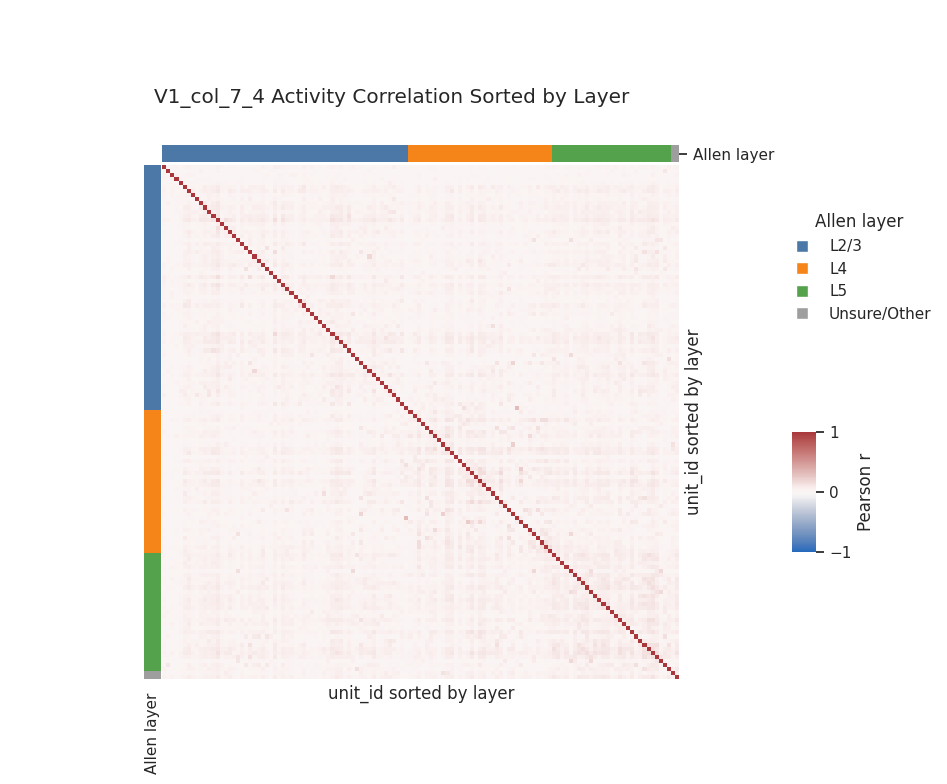

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.npy
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_allen_layer_sorted_heatmap.png


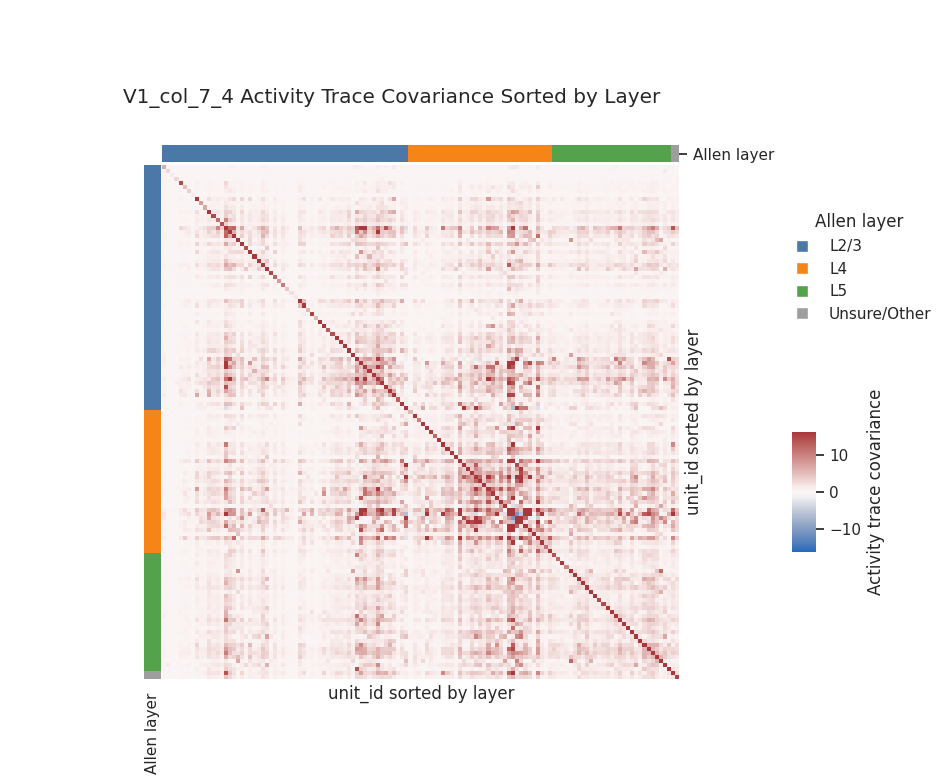

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.npy
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_allen_layer_sorted_heatmap.png


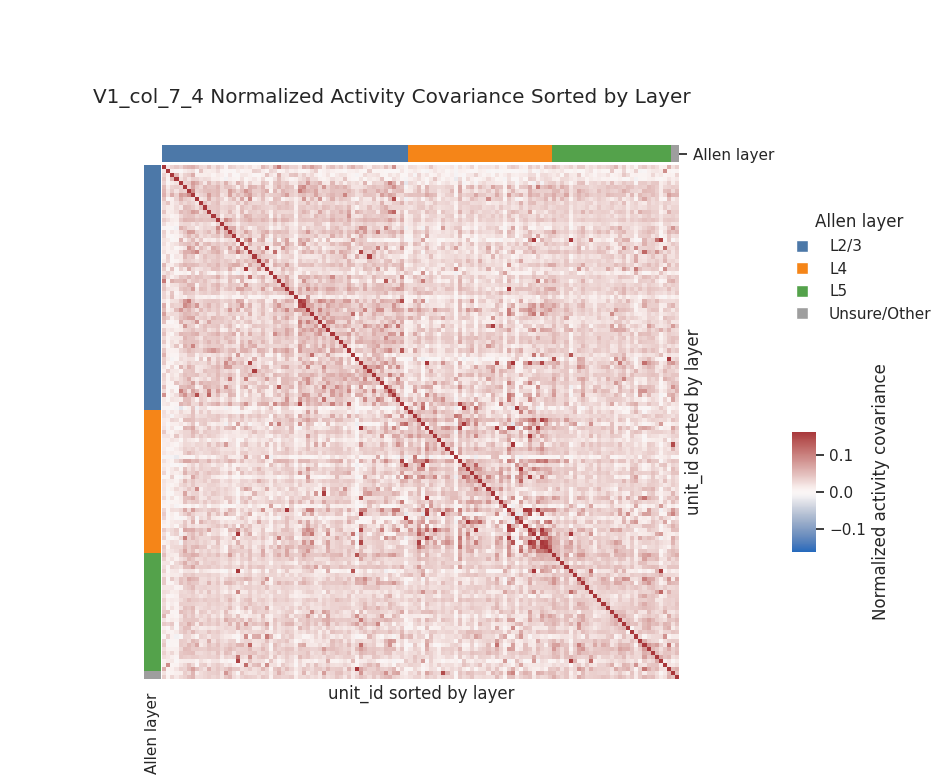

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.npy
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_allen_layer_sorted_heatmap.png


In [8]:
def save_layer_sorted_matrix_and_heatmap(df, filename_stem, title, cbar_label, fixed_limit=None):
    sorted_df = df.loc[sorted_unit_ids, sorted_unit_ids]
    csv_path = CORR_DIR / f"{filename_stem}.csv"
    save_matrix(sorted_df, csv_path)
    values = sorted_df.to_numpy(float)
    limit = fixed_limit if fixed_limit is not None else matrix_abs_limit(values)
    grid = sns.clustermap(
        sorted_df,
        row_cluster=False,
        col_cluster=False,
        row_colors=layer_color_df,
        col_colors=layer_color_df,
        colors_ratio=0.025,
        cmap="vlag",
        center=0,
        vmin=-limit,
        vmax=limit,
        xticklabels=False,
        yticklabels=False,
        figsize=(8, 8),
        cbar_kws={"label": cbar_label},
        cbar_pos=(1, 0.3, 0.03, 0.15),
    )
    grid.fig.suptitle(title, y=0.88)
    grid.ax_heatmap.set_xlabel("unit_id sorted by layer")
    grid.ax_heatmap.set_ylabel("unit_id sorted by layer")
    grid.ax_heatmap.legend(handles=legend_handles, title="Allen layer", loc="center left", bbox_to_anchor=(1.18, 0.8), frameon=False)
    png_path = CORR_DIR / f"{filename_stem.replace('_matrix', '')}_heatmap.png"
    grid.fig.savefig(png_path, bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved:", csv_path)
    print("Saved:", png_path)
    return sorted_df

corr_sorted = save_layer_sorted_matrix_and_heatmap(
    corr_df,
    "V1_col_7_4_activity_correlation_matrix_allen_layer_sorted",
    "V1_col_7_4 Activity Correlation Sorted by Layer",
    "Pearson r",
    fixed_limit=1,
)
cov_sorted = save_layer_sorted_matrix_and_heatmap(
    cov_df,
    "V1_col_7_4_activity_covariance_matrix_allen_layer_sorted",
    "V1_col_7_4 Activity Trace Covariance Sorted by Layer",
    "Activity trace covariance",
)
norm_cov_sorted = save_layer_sorted_matrix_and_heatmap(
    normalized_cov_df,
    "V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted",
    "V1_col_7_4 Normalized Activity Covariance Sorted by Layer",
    "Normalized activity covariance",
)
